In [1]:
%pip install pandas scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

file_id = "1egYkWM65LIn8Q2rVqVBTa-XjNqaJk2J_"
url = f"https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t"


loan_df = pd.read_csv(url)

: 

In [3]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2255820 entries, 0 to 2255819
Data columns (total 51 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   loan_amnt                   int64  
 1   funded_amnt                 int64  
 2   term                        int64  
 3   int_rate                    float64
 4   sub_grade                   str    
 5   emp_title                   str    
 6   emp_length                  float64
 7   home_ownership              str    
 8   annual_inc                  float64
 9   verification_status         str    
 10  loan_status                 str    
 11  purpose                     str    
 12  addr_state                  str    
 13  dti                         float64
 14  delinq_2yrs                 float64
 15  earliest_cr_line            str    
 16  inq_last_6mths              float64
 17  open_acc                    float64
 18  pub_rec                     float64
 19  revol_bal                   int6

In [4]:
# make it binary for target variable

loan_df = loan_df[loan_df['loan_status'].isin(['Fully Paid','Charged Off', 'Default', 'Does not meet the credit policy. Status:Fully Paid',
                'Does not meet the credit policy. Status:Charged Off'])]

loan_df['loan_status'] = loan_df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Fully Paid':1,
    'Does not meet the credit policy. Status:Charged Off':0
})



In [5]:
# split train test set
from sklearn.model_selection import train_test_split

X = loan_df.drop(columns='loan_status')
y = loan_df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y
                                                    )


In [6]:
# Missing Value Imputation
# Identify numerical and categorical columns
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns

# Impute Numerical Columns
median_values = X_train[num_cols].median()

X_train[num_cols] = X_train[num_cols].fillna(median_values)
X_test[num_cols] = X_test[num_cols].fillna(median_values)

# Impute Categorical Columns
for col in cat_cols:
    
    # Find the most common value in the training data
    mode_value = X_train[col].mode()[0]
    
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

# Verify Imputation
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [7]:
from sklearn.preprocessing import StandardScaler

# Only scale numerical columns, exclude target and binary columns
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
import matplotlib.pyplot as plt

X_train.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

# distribnution got better than before scaling.

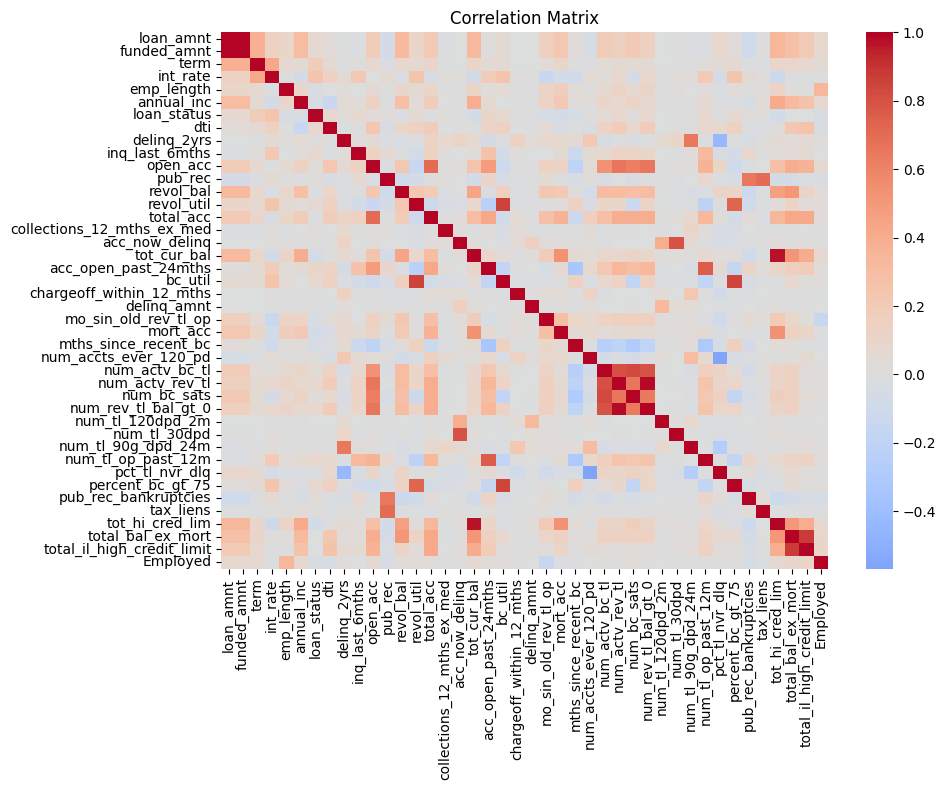

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(loan_df.select_dtypes('number').corr(), cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [10]:
X_train.info()


<class 'pandas.DataFrame'>
Index: 912720 entries, 1327503 to 1119089
Data columns (total 50 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   912720 non-null  float64
 1   funded_amnt                 912720 non-null  float64
 2   term                        912720 non-null  float64
 3   int_rate                    912720 non-null  float64
 4   sub_grade                   912720 non-null  str    
 5   emp_title                   912720 non-null  str    
 6   emp_length                  912720 non-null  float64
 7   home_ownership              912720 non-null  str    
 8   annual_inc                  912720 non-null  float64
 9   verification_status         912720 non-null  str    
 10  purpose                     912720 non-null  str    
 11  addr_state                  912720 non-null  str    
 12  dti                         912720 non-null  float64
 13  delinq_2yrs            

In [11]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 391166 entries, 1103777 to 732761
Data columns (total 50 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   391166 non-null  float64
 1   funded_amnt                 391166 non-null  float64
 2   term                        391166 non-null  float64
 3   int_rate                    391166 non-null  float64
 4   sub_grade                   391166 non-null  str    
 5   emp_title                   391166 non-null  str    
 6   emp_length                  391166 non-null  float64
 7   home_ownership              391166 non-null  str    
 8   annual_inc                  391166 non-null  float64
 9   verification_status         391166 non-null  str    
 10  purpose                     391166 non-null  str    
 11  addr_state                  391166 non-null  str    
 12  dti                         391166 non-null  float64
 13  delinq_2yrs             

In [12]:
# scaling also reduced the memory usage significantly 